In [1]:
# EDA & Visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Modelling
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Model Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from scipy.stats import zscore

np.random.seed(42)
sns.set_style("whitegrid")
df = pd.read_csv('../data/CAR DETAILS FROM CAR DEKHO.csv')
df.shape

(4340, 8)

# Exploratory Data Analysis

In [2]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


In [4]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [5]:
df.corr(numeric_only=True)

,year,selling_price,km_driven
year,1.000000,0.413922,-0.419688
selling_price,0.413922,1.000000,-0.192289
km_driven,-0.419688,-0.192289,1.000000


In [6]:
df['transmission'].value_counts()

transmission
Manual       3892
Automatic     448
Name: count, dtype: int64

In [7]:
df['year'].unique()

array([2007, 2012, 2017, 2014, 2016, 2015, 2018, 2019, 2013, 2011, 2010,
       2009, 2006, 1996, 2005, 2008, 2004, 1998, 2003, 2002, 2020, 2000,
       1999, 2001, 1995, 1997, 1992])

In [8]:
df.isna().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

## Data Visualisation

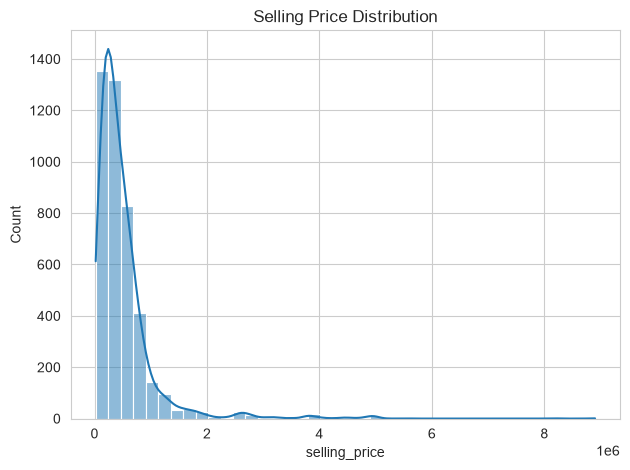

In [9]:
plt.figure()
sns.histplot(df['selling_price'], kde=True, bins=40)
plt.title('Selling Price Distribution')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'KM Driven Distribution')

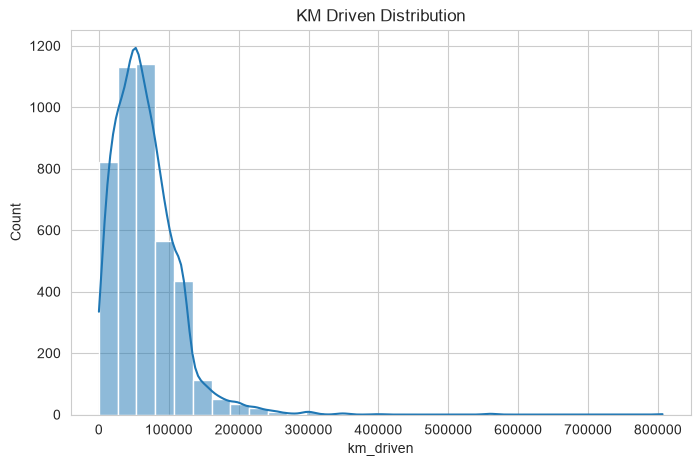

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df['km_driven'], kde=True, bins=30)
plt.title('KM Driven Distribution')

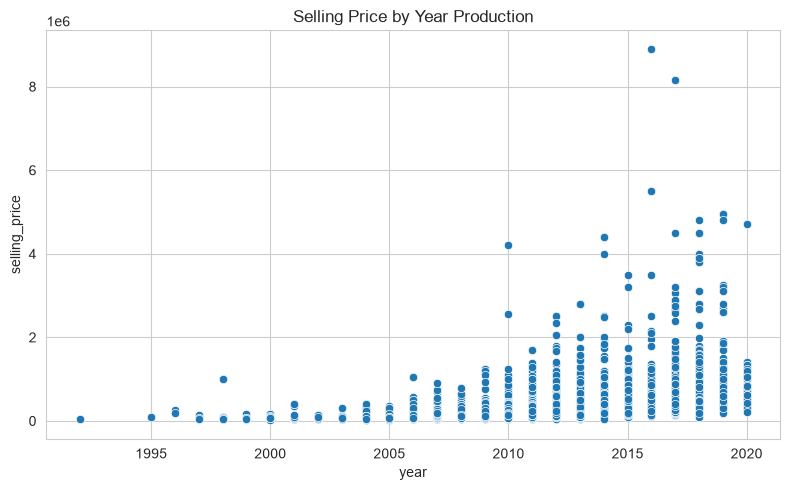

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='year', y='selling_price')
plt.title('Selling Price by Year Production')
plt.tight_layout()
plt.show()

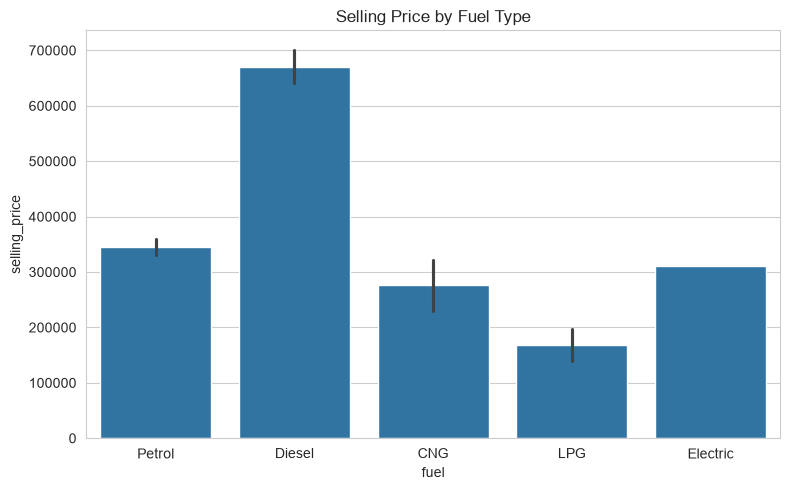

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(x='fuel', y='selling_price', data=df)
plt.title('Selling Price by Fuel Type')
plt.tight_layout()
plt.show()

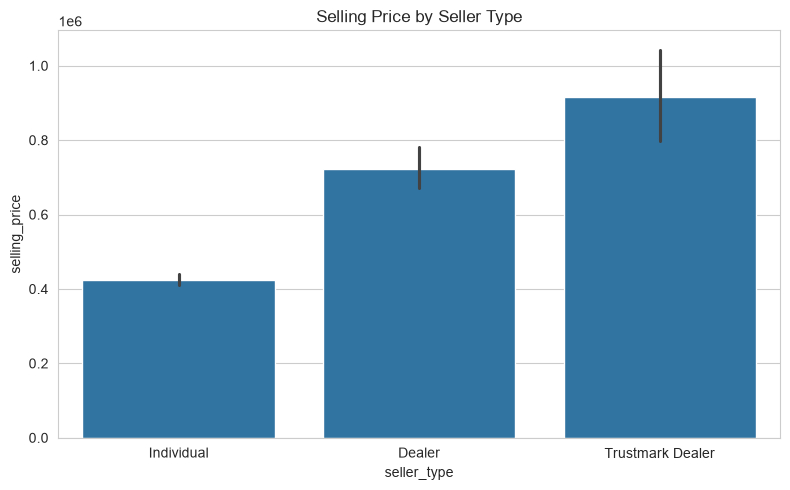

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(x='seller_type', y='selling_price', data=df)
plt.title('Selling Price by Seller Type')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Selling Price by Transmission')

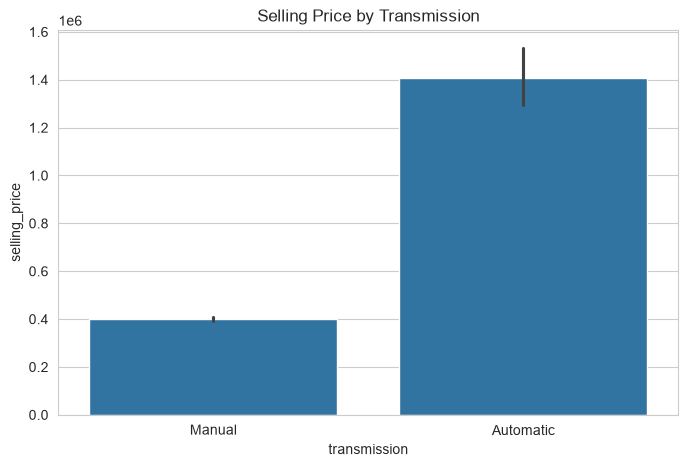

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(x='transmission', y='selling_price', data=df)
plt.title('Selling Price by Transmission')

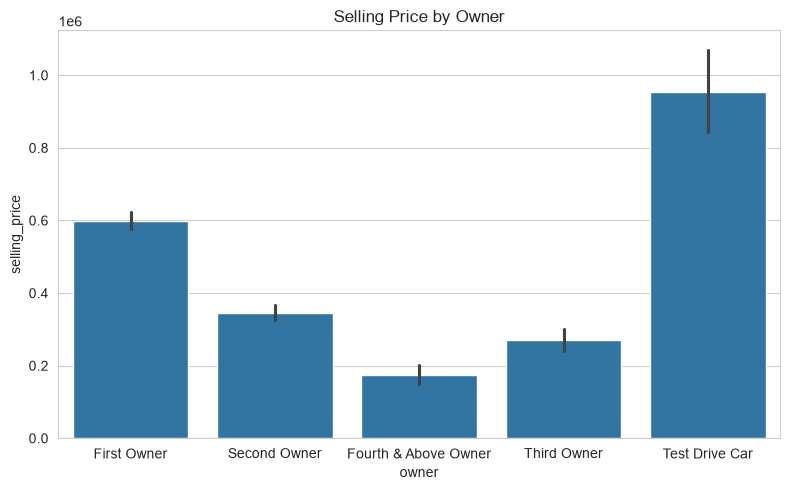

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(x='owner', y='selling_price', data=df)
plt.title('Selling Price by Owner')
plt.tight_layout()
plt.show()

## Handling and Checking Outlier

In [16]:
num_cols = df.select_dtypes(include='number').columns
num_cols

Index(['year', 'selling_price', 'km_driven'], dtype='str')

In [17]:
num_cols = num_cols.drop('year')
num_cols

Index(['selling_price', 'km_driven'], dtype='str')

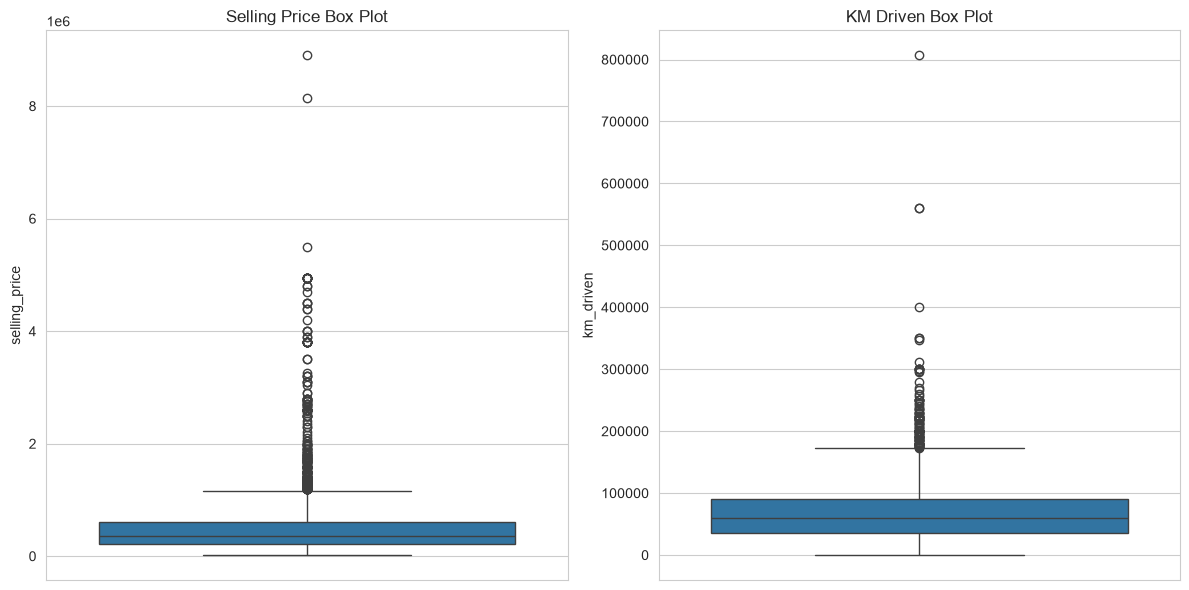

In [18]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
sns.boxplot(ax=ax[0], data=df['selling_price'])
ax[0].set(title='Selling Price Box Plot')

sns.boxplot(ax=ax[1], data=df['km_driven'])
ax[1].set(title='KM Driven Box Plot')

plt.tight_layout()
plt.show()

In [19]:
# Find the ZScore
z_scores = zscore(df[num_cols])

# Detect the outliers
outliers = np.abs(z_scores) > 3

# Print and check all the outliers
print(pd.DataFrame(outliers, columns=num_cols).sum())

data_outlier_rows = df[(outliers).any(axis=1)]
data_outlier_rows

selling_price    92
km_driven        55
dtype: int64


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
69,Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII,2010,280000,350000,Diesel,Individual,Manual,Second Owner
70,Toyota Corolla Altis Diesel D4DG,2011,350000,230000,Diesel,Individual,Manual,First Owner
89,Mercedes-Benz S-Class S 350d Connoisseurs Edition,2017,8150000,6500,Diesel,Dealer,Automatic,First Owner
96,Audi A8 4.2 TDI,2013,2800000,49000,Diesel,Dealer,Automatic,First Owner
101,Mercedes-Benz E-Class Exclusive E 200 BSIV,2018,4500000,9800,Petrol,Dealer,Automatic,First Owner
...,...,...,...,...,...,...,...,...
4255,Mahindra XUV500 W8 2WD,2014,650000,218000,Diesel,Individual,Manual,Second Owner
4275,Mahindra XUV500 W8 2WD,2014,650000,218000,Diesel,Individual,Manual,Second Owner
4286,Fiat Punto 1.3 Emotion,2010,130000,210000,Diesel,Individual,Manual,Second Owner
4304,Audi Q5 3.0 TDI Quattro Technology,2018,3899000,22000,Diesel,Dealer,Automatic,First Owner


In [20]:
df_clean = df[(z_scores < 3) & (z_scores > -3)]

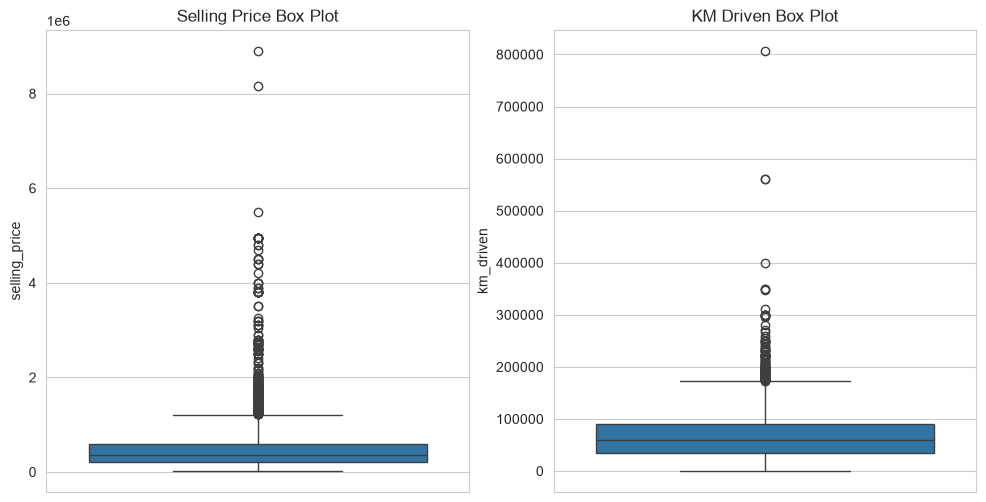

<Figure size 640x480 with 0 Axes>

In [21]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
sns.boxplot(ax=ax[0], data=df_clean['selling_price'])
ax[0].set(title='Selling Price Box Plot')

sns.boxplot(ax=ax[1], data=df_clean['km_driven'])
ax[1].set(title='KM Driven Box Plot')

plt.show()
plt.tight_layout()

# Data Preprocessing

In [22]:
# creating a pipeline
cat_feat = ['fuel', 'seller_type', 'transmission', 'owner']

preprocessor = ColumnTransformer(
    transformers = [
        ('onehot',  OneHotEncoder(handle_unknown='ignore'), cat_feat)
    ], remainder='passthrough'
)

In [23]:
# Data Splitting
X = df_clean.drop(['selling_price', 'name'], axis=1)
y = df_clean['selling_price']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6826, 6), (1707, 6), (6826,), (1707,))

# Modelling

In [24]:
regression_model = {'Lasso': Lasso(),
                    'LinearRegression': LinearRegression(),
                    'RandomForestRegressor': RandomForestRegressor()}
model_result = {}

In [25]:
for model_name, model in regression_model.items():
    model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('model', model)])
    print(f'Fitting Model {model_name}...')
    model_pipeline.fit(X_train, y_train)

    print(f'Scoring {model_name}...')
    model_result[model_name] = model_pipeline.score(X_test, y_test)

Fitting Model Lasso...
Scoring Lasso...
Fitting Model LinearRegression...
Scoring LinearRegression...
Fitting Model RandomForestRegressor...


d:\Development\Machine Learning\env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.878476e+13, tolerance: 1.387e+11
  model = cd_fast.enet_coordinate_descent(


Scoring RandomForestRegressor...


In [26]:
model_result

{'Lasso': 0.4014534447156445,
 'LinearRegression': 0.4012652633062954,
 'RandomForestRegressor': 0.6190311515308143}

# Hyper Parameter Tunning

Random Search Cross Validation

In [27]:
rf_reg_rs = Pipeline(steps=[('preprocessor', preprocessor),
                            ('model', RandomForestRegressor())])

param_distribution = {'model__n_estimators': [100, 200, 500, 1000],
                      'model__max_depth': [None, 5, 10, 20, 30],
                      'model__max_features': ['sqrt', 'log2', None]}

rf_rdcv = RandomizedSearchCV(
    estimator=rf_reg_rs,
    param_distributions=param_distribution,
    n_iter=5,
    cv=5,
    verbose=2,
    random_state=42
)

rf_rdcv.fit(X_train, y_train)
rf_rdcv.score(X_test, y_test)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=100; total time=   0.5s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=100; total time=   0.5s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=100; total time=   0.5s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=100; total time=   0.6s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=100; total time=   0.5s
[CV] END model__max_depth=None, model__max_features=log2, model__n_estimators=200; total time=   1.2s
[CV] END model__max_depth=None, model__max_features=log2, model__n_estimators=200; total time=   1.1s
[CV] END model__max_depth=None, model__max_features=log2, model__n_estimators=200; total time=   1.1s
[CV] END model__max_depth=None, model__max_features=log2, model__n_estimators=200; total time=   1.1s
[CV] END model__max_de

0.6247480012235369

In [28]:
rf_rdcv.best_params_

{'model__n_estimators': 200,
 'model__max_features': None,
 'model__max_depth': 20}

In [29]:
param_grid = {'model__n_estimators': [1, 100, 200],
                      'model__max_depth': [None, 5],
                      'model__max_features': ['sqrt', 'log2']}

rf_gscv = GridSearchCV(
    estimator=rf_reg_rs,
    param_grid=param_grid,
    cv=5,
    verbose=2,
)

rf_gscv.fit(X_train, y_train)
rf_gscv.score(X_test, y_test)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=1; total time=   0.0s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=1; total time=   0.0s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=1; total time=   0.0s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=1; total time=   0.0s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=1; total time=   0.0s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=100; total time=   0.6s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=100; total time=   0.5s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=100; total time=   0.5s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=100; total time=   0.4s
[CV] END model__max_depth=None,

0.6287184325403715